# Project 3 - Sales Analysis - Visualisations

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Show plots to attempt to answer hypothesis


## Inputs

CSV files used:

Sales_InvoiceData_Visualization.csv


## Outputs

Plots to show the data and attempt to answer the hypothesis



## Additional Comments

- Using as many of the plot libraries as possible to see which produces the best results for each hypothesis.
- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


# Hypothesis Being Tested

- What were the highest sales per territory for last year?
- Who were the top 20 customer by sales for last year?
- Who were the bottom 20 customer by sales for last year?
- What was the sales by product family for last the two years?
- What was the total amount of credits against normal invoices for last year?
- What was the percentage of ship methods used last year?
- What were the sales per customer per territory for last year?
- What was the total credits per customer for last year by month?

## Initalise Working Environment

In [2]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import math

#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 
from mpl_toolkits.mplot3d import axes3d

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [3]:
#DataFrame vars for visualisation
dfSales_DataSet = None
dfSales_DataSet_Filtered = None
dfSunburst_DataSet = None
dfSales_DataSet_GroupBy = None
dfSales_DataSet_Summary = None
dfSales_DataSet_Final = None
#just in case need to add more Feature Engineering
dfSales_DataSet_Work = None
dfSales_DataSet_Temp = None

#other vars
lstStoreRanges = []
lstLabels = []
objStore = None
intYear = 0
fig = None
ax = None
objCurrentStore  = None
lstMarkdownColumns = None
dictDataFrames = dict()
intNum = 0
intNum2 = 0
intNum3 = 0
strTemp = ""
intStartYear = 0
intEndYear = 0


## Set Current Directory To Base Project Directory

In [4]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_DataSet_Work

In [5]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
dfSales_DataSet_Work = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]

3 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_GroupedByTerritory_Visualisation.csv
Sales_InvoiceData_GroupedByCustomer_Visualisation.csv
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


## Transform Date Column To Datetime Format

In [6]:
#transform Date to datetime
dfSales_DataSet_Work["InvoiceDate"] = pd.to_datetime(dfSales_DataSet_Work["InvoiceDate"], format="%d/%m/%Y")

#check schema
dfSales_DataSet_Work.dtypes

Unnamed: 0                 int64
InvoiceID                 object
InvoiceDate       datetime64[us]
ItemID                       str
ItemName                     str
ProductFamily                str
InvoiceQty               float64
InvoiceAmt               float64
CustomerID                   str
TerritoryCodes               str
ShipMethod                   str
Day                        int64
Month                      int64
Year                       int64
Quarter                    int64
YearMonth                  int64
dtype: object

---

## Visualisations!

Each hypothesis will be visualised using:

- pandas
- matplotlib.pyplot
- plotly.express
- seaborn


## Hypothesis 1

What were the highest sales per territory for last year?

Highest Sales Per Territory For Last Year Over Last 12 Months


,TerritoryCodes,InvoiceAmt
0,Central/E.Anglia,2373.98
1,EU,24240.00
2,EU - OTHER EUROPE,6792.50
3,EU INV,2750.40
4,East Midlands,1402.50
5,House Account,13931.67
6,London,3789.00
7,Midlands,11975.76
8,Midlands and East,12350.00
9,Midlands and West,5614.99


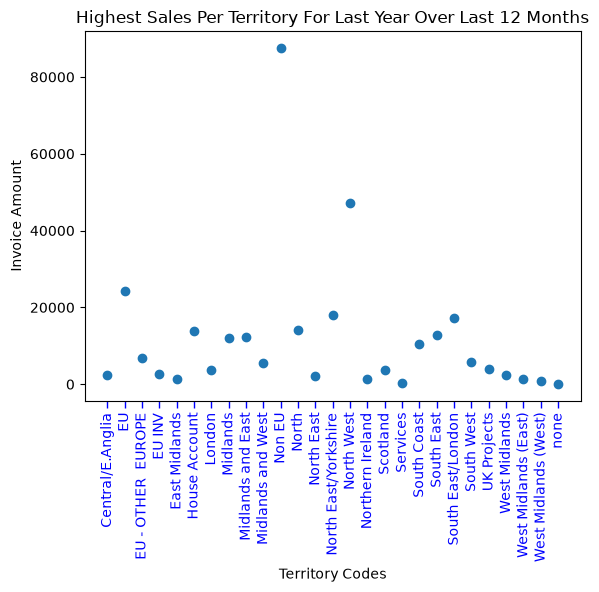

In [7]:
#visualisation for hypothesis 1 - what were the highest sales per territory for last year?

#filter DataFrame for last 12 months
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#create new DataFrame with one TerritoryCodes entry per YearMonth with the MAX InvoiceAmt in it
dfSales_DataSet_Temp = dfSales_DataSet_Filtered.groupby(["TerritoryCodes"], as_index=False)["InvoiceAmt"].max()      
                                                    
fig, ax = plt.subplots()
ax.scatter(x=dfSales_DataSet_Temp["TerritoryCodes"], y=dfSales_DataSet_Temp["InvoiceAmt"])
ax.title.set_text("Highest Sales Per Territory For Last Year Over Last 12 Months")
ax.set_xlabel("Territory Codes")
ax.set_ylabel("Invoice Amount")

ax.tick_params("x", labelrotation=90, labelsize=10, labelcolor="blue", length=5, width=1, colors="blue") 
           
print("Highest Sales Per Territory For Last Year Over Last 12 Months") 
print("=" * len("Highest Sales Per Territory For Last Year Over Last 12 Months"))
dfSales_DataSet_Temp

## Observations

Looks decent, certainly answers the hypothesis

## Conclusions - Hypothesis 1

Simple but effective reporting, clearly show the most lucrative territories, could be used for targeted marketing
for those areas with low sales

## Hypothesis 2

Who were the top 20 customers by sales for last year?

In [8]:
#Who were the top 20 customers by sales for last year?

#first filter by last year (2016)
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#group by CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby("CustomerID")["InvoiceAmt"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

#sort data
dfSales_DataSet_Filtered.sort_values("InvoiceAmt", ascending=False)

fig = px.bar(
    dfSales_DataSet_Filtered.head(20),
    x="CustomerID",
    y="InvoiceAmt",
    color="InvoiceAmt",
    color_continuous_scale="Solar",
    title="Top 20 Customers By Sales For Last 12 Months"
)

fig.update_layout(
    xaxis_title="Customer ID",
    yaxis_title="Total Sales (£)",
    coloraxis_colorbar=dict(title="Total Sales (£)"),
    template="plotly_white",
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="black")
)

fig.show()

## Observations

Answers the hypothesis, clear winner for customers 628 and 2018, does propose even more analysis questions!

## Conclusions - Hypothesis 2

Very clear plot, customer will like the simplicity of the visualiastion, another candidate for targeted marketing

## Hypothesis 3

Who were the bottom 20 customer by sales for last year?

In [9]:
#Who were the bottom 20 customers by sales for last year?

#first filter by last year (2016)
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#to stop customer being shown who have NO sales delete all records where InvoiceAmt is 0
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[dfSales_DataSet_Filtered["InvoiceAmt"] > 0]

#group by CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby("CustomerID")["InvoiceAmt"]
    .sum()
    .sort_values(ascending=False)
    .tail(20)
    .reset_index()
)

#sort data
dfSales_DataSet_Filtered.sort_values("InvoiceAmt", ascending=False)

fig = px.bar(
    dfSales_DataSet_Filtered.head(20),
    x="CustomerID",
    y="InvoiceAmt",
    color="InvoiceAmt",
    color_continuous_scale="Solar",
    title="Bottom 20 Customers By Sales For Last 12 Months"
)

fig.update_layout(
    xaxis_title="Customer ID",
    yaxis_title="Total Sales (£)",
    coloraxis_colorbar=dict(title="Total Sales (£)"),
    template="plotly_white",
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="black")
)

fig.show()

## Observations

Answers the hypothesis, just what I was looking for, clean, simple, direct and potentially shocking!


In [10]:
#special plot for *all* customers with sales *below* zero!

#first filter by last year (2016)
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#to stop customer being shown who have NO sales delete all records where InvoiceAmt is 0
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[dfSales_DataSet_Filtered["InvoiceAmt"] < 0]

#group by CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby("CustomerID")["InvoiceAmt"]
    .sum()
    .sort_values(ascending=False)
  #  .tail(20)
    .reset_index()
)



#sort data
dfSales_DataSet_Filtered.sort_values("InvoiceAmt", ascending=False)

fig = px.bar(
    dfSales_DataSet_Filtered.head(20),
    x="CustomerID",
    y="InvoiceAmt",
    color="InvoiceAmt",
    color_continuous_scale="Solar",
    title="All Customers With Negative Sales For Last 12 Months"
)

fig.update_layout(
    xaxis_title="Customer ID",
    yaxis_title="Total Sales (£)",
    coloraxis_colorbar=dict(title="Total Sales (£)"),
    template="plotly_white",
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="black")
)

fig.show()

## Observations: Customers With Negative Sales Values

Really interesting, question for customer to ask themselves is **why** this has been allowed to happen!

Are they really suggesting that they sell products for less than zero? I think we need to look at the DataFrame
to get the answers

In [11]:
#special plot for *all* customers with sales *below* zero!

#first filter by last year (2016)
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#to stop customer being shown who have NO sales delete all records where InvoiceAmt is 0
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[dfSales_DataSet_Filtered["InvoiceAmt"] < 0]

#filter for customer, invoice id, invoie amount
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[["InvoiceAmt", "CustomerID","InvoiceID"]] 
dfSales_DataSet_Filtered.sort_values("InvoiceAmt", ascending=False)

#show DataFrame
dfSales_DataSet_Filtered

,InvoiceAmt,CustomerID,InvoiceID
161070,-808.34,526,CM259611
163352,-53.34,589,CM260609


## Observation: DataFrame

This answers our question, the 2 customers with negative values were because of **credit memos**

So this is not a data error, this is the effect of crediting the customer, question for the business is how often does
this happen?

## Conclusions - Hypothesis 3

Answers the hypothesis, with the previous plot forms a powerful tool for seeing the extremes of profitability,
however, there are values *below* 0 so will add a plot to show that below

## Hypothesis 4

What was the total amount of credits issued for last year?

In [12]:
#special plot for *all* customers with sales *below* zero!

#first filter by last year (2016)
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#to stop customer being shown who have NO sales delete all records where InvoiceAmt is 0
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[dfSales_DataSet_Filtered["InvoiceAmt"] < 0]

#group by CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby("CustomerID")["InvoiceAmt"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

#sort data
dfSales_DataSet_Filtered.sort_values("InvoiceAmt", ascending=False)

fig = px.bar(
    dfSales_DataSet_Filtered.head(20),
    x="CustomerID",
    y="InvoiceAmt",
    color="InvoiceAmt",
    color_continuous_scale="Solar",
    title="All Customers With Credit Memos For Last 12 Months"
)

fig.update_layout(
    xaxis_title="Customer ID",
    yaxis_title="Total Sales (£)",
    coloraxis_colorbar=dict(title="Total Sales (£)"),
    template="plotly_white",
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="black")
)

fig.show()

## Observations

Answers the hypothesis, nice and simple, what irony we did this plot in the previous data exploration, works

## Hypothesis 5

What was the percentage of ship methods used last year?

In [13]:
#What was the percentage of ship methods used last year?

#filter DataFrame for last 12 months
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#create new DataFrame with one ShipMethod entry per YearMonth with the MAX InvoiceAmt in it
dfSales_DataSet_Temp = dfSales_DataSet_Filtered.groupby(["ShipMethod"], as_index=False)["InvoiceAmt"].max()      
                             
#group by ShipMethodand get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby("ShipMethod")["InvoiceAmt"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.pie(
    dfSales_DataSet_Filtered,
    names="ShipMethod",
    values="InvoiceAmt",
    title="Percentage of Ship Methods Used Last Year",
    color_discrete_sequence=px.colors.qualitative.Set3,
    height=800,
    width=800
)
fig.update_layout(
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="black")
)

fig.show()

           
print("Percentage of Ship Methods Used Last Year") 
print("=" * len("Percentage of Ship Methods Used Last Year"))
dfSales_DataSet_Temp

Percentage of Ship Methods Used Last Year


,ShipMethod,InvoiceAmt
0,Amtrak,3387.00
1,Customer Collection,13931.67
2,Despatch Next Day,18085.84
3,Export,87500.00
4,Express Despatch Next Day,1592.46
5,Interlink,17212.80
6,Orbik Transport,2373.98
7,Own Transport,53.24
8,UK Carrier,15462.90


## Conclusions - Hypothesis 5

Nice plot, again easy to see, probably wanted to see it, if thinking of changing couriers and seeing what the 
customers use most

## Hypothesis 6 

What were the total sales per customer per territory for last year?

In [ ]:
#What were the total sales per customer per territory for last year?

intStartYear = dfSales_DataSet_Work["Year"].max() -1
#filter DataFrame for last 12 months
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == dfSales_DataSet_Work["Year"].max() -1]

#to stop customer being shown who have NO sales delete all records where InvoiceAmt is 0
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered[dfSales_DataSet_Filtered["InvoiceAmt"] > 0]
#group by TerritoryCodes and CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby(["TerritoryCodes", "CustomerID"], as_index=False)["InvoiceAmt"]
    .sum()
    .sort_values("InvoiceAmt", ascending=False)
)


fig = px.sunburst(
    dfSales_DataSet_Filtered,
    path=[
        "TerritoryCodes",
        "CustomerID",
    ],
    values="InvoiceAmt",
    color="InvoiceAmt",
    color_continuous_scale="Solar",
    title=f"Sales Per Customer Per Territory For {intStartYear}",
    height=800,
    width=800,
    hover_data={
        "InvoiceAmt": ":,.2f",
        "TerritoryCodes": True,
        "CustomerID": True,
    }
)

fig.update_layout(
    title_x=0.3,
    title_font=dict(
        size=20,
        family="Arial",
        color="black"
    )
)

fig.update_traces(
    hovertemplate=
        "Invoice Amount: £%{customdata[0]:,.2f}<br>" +
        "Territory: %{customdata[1]}<br>" +
        "Customer: %{customdata[2]}<br>" +
        "<extra></extra>"
)

fig.show()



## Conclusions - Hypothesis 6

Nice interactive plot glad customer did not want to see individual invoices as that would have meant trying to show a huge amount of data in the plot
which would have slowed it dramatically!

## Hypothesis 7: What Was The Sales By Product Family For Last The Two Years?

In [ ]:
#what was the sales by product family for last the two years?
intStartYear = dfSales_DataSet_Work["Year"].max() -1
intEndYear = dfSales_DataSet_Work["Year"].max()

#filter DataFrame for last 12 months
dfSales_DataSet_Filtered = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] >= dfSales_DataSet_Work["Year"].max() -1]

#remove zero/negative amounts
dfSales_DataSet_Filtered  = dfSales_DataSet_Filtered [dfSales_DataSet_Filtered ["InvoiceAmt"] > 0]

#sort by year
dfSales_DataSet_Filtered = dfSales_DataSet_Filtered.sort_values(by=["Year"], ascending=[True])

#group by CustomerID and get sum of InvoiceAmt
dfSales_DataSet_Filtered = (
    dfSales_DataSet_Filtered
    .groupby(["Year", "ProductFamily"])["InvoiceAmt"]
    .sum()
    .reset_index()
)

#print first 3 dataframes in each column 
dfSales_DataSet_Temp = dfSales_DataSet_Filtered.loc[ dfSales_DataSet_Filtered["Year"].isin([intStartYear, intEndYear]),
                                    ["Year", "ProductFamily", "InvoiceAmt"] ]    
#convert year to string
dfSales_DataSet_Temp = dfSales_DataSet_Temp.astype({"Year": str})
        
fig = px.scatter(
    dfSales_DataSet_Temp,
    x="ProductFamily",
    y="InvoiceAmt",
    color="Year",
    height=800,
    width=1000,
    title=f"Comparing Sales By Product Family For {intEndYear} Against {intStartYear}"
)

plt.style.use("dark_background")
#from chatGPT
fig.update_xaxes(type="category", categoryorder="category ascending")
#end from chatGPT
fig.update_layout(xaxis_title="Product Family", yaxis_title="Invoice Amount", template="plotly_dark") 
fig.update_layout(
    title_x=0.5,
    title_font=dict(size=20, family="Arial", color="white")
)

#make so dots on plot are more readable
fig.update_traces(marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')), selector=dict(mode='markers'))
fig.show()

print("Sales By Product Family For Last The Two Years")
print("=" * len("Sales By Product Family For Last The Two Years"))
dfSales_DataSet_Filtered



Sales By Product Family For Last The Two Years


,Year,ProductFamily,InvoiceAmt
0,2016,ADAC,24693.20
1,2016,AM(Pals),17332.41
2,2016,Accessories,97191.95
3,2016,Arc,431131.80
4,2016,Arrian,81820.48
...,...,...,...
190,2017,Slave Inverter,30369.69
191,2017,Starters,18284.52
192,2017,TIEL,29272.24
193,2017,Tiel,68666.96


## Conclusions - Hypothesis 7

Looks good, clearly shows the correlations between the two years, interesting that even though the data is sorted
by year then product family (as the above DataFrame shows), the plot renderer has the last 3 product families in
the *wrong* order!

## Global Conclusions

Decent plots for the hypothesis, will experiment with different types for the streamlit dashboard